In [2]:
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.datasets import fetch_covtype
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, log_loss
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch import Tensor

import torch._dynamo
import torch.utils.benchmark as benchmark
from torch.optim import Optimizer
from torchinfo import summary
from torch.autograd import Function

In [3]:
def zeropower_via_newtonschulz5(G: Tensor, steps: int) -> Tensor:
    assert G.ndim >= 2
    a, b, c = 3.4445, -4.7750, 2.0315
    X = G.clone().float()
    if G.size(-2) > G.size(-1):
        X = X.mT
    X = X / (X.norm(dim=(-2, -1), keepdim=True) + 1e-7)
    for _ in range(steps):
        A = X @ X.mT
        B = b * A + c * A @ A
        X = a * X + B @ X
    if G.size(-2) > G.size(-1):
        X = X.mT
    return X

class Muon(Optimizer):
    def __init__(self, params, lr=0.02, weight_decay=0.01, momentum=0.95, nesterov=True, ns_steps=5):
        defaults = dict(lr=lr, weight_decay=weight_decay, momentum=momentum, nesterov=nesterov, ns_steps=ns_steps)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self):
        for group in self.param_groups:
            lr = group["lr"]
            weight_decay = group["weight_decay"]
            momentum = group["momentum"]
            nesterov = group["nesterov"]
            ns_steps = group["ns_steps"]

            for p in group["params"]:
                if p.grad is None:
                    continue
                g = p.grad.data

                if g.ndim < 2:
                    continue  # skip scalars, biases, etc.

                state = self.state[p]
                if "momentum_buffer" not in state:
                    state["momentum_buffer"] = torch.zeros_like(g)

                buf = state["momentum_buffer"]
                buf.mul_(momentum).add_(g)

                if nesterov:
                    g = g + momentum * buf
                else:
                    g = buf

                if g.ndim == 4:
                    g = g.view(g.size(0), -1)

                g = zeropower_via_newtonschulz5(g, steps=ns_steps).view_as(p)

                p.mul_(1 - lr * weight_decay)
                p.add_(g, alpha=-lr)

In [4]:
torch._dynamo.config.cache_size_limit = 16

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
device = torch.device("cpu")

In [5]:
df = sns.load_dataset('diamonds')
df = df[['carat', 'depth', 'table', 'price', 'x', 'y', 'z', 'cut']]

df['cut'] = (df['cut'] == 'Ideal').astype(int)

X = df.drop('cut', axis=1)
y = df['cut']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long).to(device)

print(X.shape)
print(y.shape)

ideal_percentage = df['cut'].mean() * 100
print(f"Percentage of diamonds with 'Ideal' cut: {ideal_percentage:.2f}%")

model = LogisticRegression(penalty='l2', C=0.001, max_iter=10000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

y_pred_proba = model.predict_proba(X_test)
loss = log_loss(y_test, y_pred_proba)

print(f"Test Accuracy: {accuracy * 100:.2f}%")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Ideal', 'Ideal']))
print(model.coef_)
print(f"Log Loss: {loss:.6f}")

(53940, 7)
(53940,)
Percentage of diamonds with 'Ideal' cut: 39.95%
Test Accuracy: 79.30%
Classification Report:
              precision    recall  f1-score   support

   Not Ideal       0.82      0.85      0.83      6496
       Ideal       0.75      0.71      0.73      4292

    accuracy                           0.79     10788
   macro avg       0.79      0.78      0.78     10788
weighted avg       0.79      0.79      0.79     10788

[[-0.15688782 -0.46189194 -1.57368125  0.22509094 -0.08309788 -0.03167662
  -0.08671039]]
Log Loss: 0.451068


/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered

In [6]:
def train(model, criterion, optimizers, epochs):
    print(summary(model, input_data=X_train_tensor))

    torch.set_printoptions(threshold=float('inf'))
    for name, param in model.named_parameters():
        print(name)
        print(param)

    @torch._dynamo.explain
    def run_model(x):
        return model(x)

    run_model(X_train_tensor) # type: ignore

    best_test_loss = float('inf')

    train_losses = []
    test_losses = []

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

    schedulers = [
        torch.optim.lr_scheduler.LinearLR(opt, start_factor=1.0, end_factor=0.05, total_iters=epochs)
        for opt in optimizers
    ]

    for epoch in range(1, epochs + 1):
        model.train()
        for opt in optimizers:
            opt.zero_grad()

        train_outputs = model(X_train_tensor)
        train_loss = criterion(train_outputs, y_train_tensor)
        train_loss.backward()

        for opt in optimizers:
            opt.step()

        model.eval()
        with torch.no_grad():
            test_outputs = model(X_test_tensor)
            test_loss = criterion(test_outputs, y_test_tensor)
            test_predictions = torch.argmax(test_outputs, dim=1)
            test_accuracy = (test_predictions == y_test_tensor).sum().item() / y_test_tensor.size(0)

        train_losses.append(train_loss.item())
        test_losses.append(test_loss.item())

        if test_loss.item() < best_test_loss:
            best_test_loss = test_loss.item()

        for scheduler in schedulers:
            scheduler.step()

        if epoch % 1 == 0:
            print(f"Epoch {epoch}/{epochs}, Train Loss: {train_loss.item():.32f}, Test Loss: {test_loss.item():.8f}, Test Accuracy: {test_accuracy:.4f}")

    if torch.cuda.is_available():
        gc.collect()
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

        print(f"[GPU] Peak memory allocated: {torch.cuda.max_memory_allocated() / 1024 ** 2:.2f} MB")
        print(f"[GPU] Peak memory reserved: {torch.cuda.max_memory_reserved() / 1024 ** 2:.2f} MB")

    print()
    print(f"Lowest Test Loss: {best_test_loss:.8f}")

    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(test_losses, label='Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Test Loss Over Epochs')
    plt.legend()
    plt.grid(True)
    plt.show()  

In [12]:
class CustomActivation(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        self.a = nn.Parameter(torch.full((num_features,), 1.0))
        self.b = nn.Parameter(torch.full((num_features,), 1.0))

    def forward(self, x):
        return torch.where(x >= 0, self.a * x, self.b * x)


class StableNN(nn.Module):
    def __init__(self, n, num_layers=2):
        super().__init__()
        self.pre_norms = nn.ModuleList()
        self.linears = nn.ModuleList()
        self.activations = nn.ModuleList()
        self.post_norms = nn.ModuleList()

        for _ in range(num_layers):
            self.pre_norms.append(nn.BatchNorm1d(n, affine=False, track_running_stats=True))

            self.linears.append(nn.Linear(n, n, bias=False))
            with torch.no_grad():
                nn.init.zeros_(self.linears[-1].weight) # type: ignore

            self.activations.append(CustomActivation(n))
            self.post_norms.append(nn.BatchNorm1d(n, affine=False, track_running_stats=True))

            n *= 2

        self.final_norm = nn.BatchNorm1d(n, affine=False, track_running_stats=True)
        self.final_linear = nn.Linear(n, 2, bias=True)
        with torch.no_grad():
            nn.init.zeros_(self.final_linear.weight)
            nn.init.zeros_(self.final_linear.bias)

    def forward(self, x):
        for prenorm, linear, activation, postnorm in zip(self.pre_norms, self.linears, self.activations, self.post_norms):
            residual = x

            x = prenorm(x)
            x = linear(x)

            x = torch.cat([residual, activation(postnorm(x + residual))], dim=1)

        x = self.final_norm(x)
        return self.final_linear(x)

In [15]:
model = torch.compile(StableNN(n=X.shape[1], num_layers=8).to(device))
criterion = nn.CrossEntropyLoss()

optimizers = [
    optim.Rprop(model.parameters(), lr=0.0, step_sizes=(torch.finfo(torch.float32).smallest_normal, torch.inf))
]

train(model, criterion, optimizers, epochs=5000)

for name, param in model.named_parameters(): # type: ignore
    print(name)
    print(param)

Layer (type:depth-idx)                   Output Shape              Param #
OptimizedModule                          [43152, 2]                --
├─StableNN: 1-1                          [43152, 2]                --
│    └─ModuleList: 2-29                  --                        --
│    │    └─BatchNorm1d: 3-1             [43152, 7]                --
│    └─ModuleList: 2-30                  --                        (recursive)
│    │    └─Linear: 3-2                  [43152, 7]                49
│    └─ModuleList: 2-31                  --                        --
│    │    └─BatchNorm1d: 3-3             [43152, 7]                --
│    └─ModuleList: 2-32                  --                        (recursive)
│    │    └─CustomActivation: 3-4        [43152, 7]                14
│    └─ModuleList: 2-29                  --                        --
│    │    └─BatchNorm1d: 3-5             [43152, 14]               --
│    └─ModuleList: 2-30                  --                        

KeyboardInterrupt: 

Layer (type:depth-idx)                   Output Shape              Param #
OptimizedModule                          [43152, 2]                --
├─StableNN: 1-1                          [43152, 2]                --
│    └─ModuleList: 2-5                   --                        --
│    │    └─BatchNorm1d: 3-1             [43152, 7]                --
│    └─ModuleList: 2-6                   --                        (recursive)
│    │    └─Linear: 3-2                  [43152, 7]                49
│    └─ModuleList: 2-7                   --                        --
│    │    └─BatchNorm1d: 3-3             [43152, 7]                --
│    └─ModuleList: 2-8                   --                        (recursive)
│    │    └─CustomActivation: 3-4        [43152, 7]                14
│    └─ModuleList: 2-5                   --                        --
│    │    └─BatchNorm1d: 3-5             [43152, 14]               --
│    └─ModuleList: 2-6                   --                        

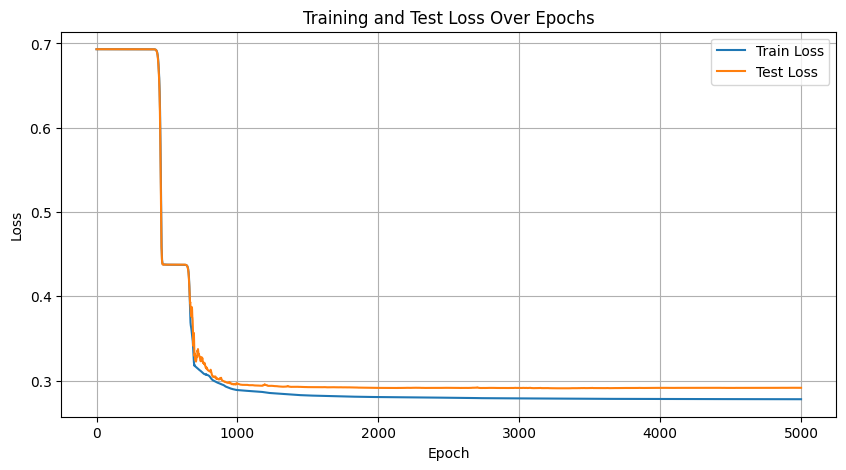

_orig_mod.linears.0.weight
Parameter containing:
tensor([[-3.6518e-17, -4.1840e-02,  5.5064e-03, -3.7009e-02, -4.7883e-01,
         -4.6989e-02, -1.4629e-04],
        [ 1.7055e-01, -2.0544e-01,  1.8785e-01, -6.1212e-02, -2.0399e-01,
          9.5081e-02, -2.5004e-08],
        [ 1.9056e-02,  2.5158e-01,  7.8994e-26, -1.0341e-02, -1.3693e-02,
         -2.0098e-03,  5.9316e-04],
        [ 3.0074e-02, -1.4798e-01, -2.6149e-02, -2.3450e-02, -5.0663e-02,
         -2.4280e-01,  4.6437e-02],
        [-8.7955e-01,  1.6312e-02,  2.3352e-02,  2.2953e-03, -2.7205e-18,
         -2.3304e-01, -2.9648e-02],
        [-1.4860e-02,  1.0714e-03,  1.4793e-03, -3.6522e-03, -9.5565e-01,
          1.3494e-27,  2.3694e-04],
        [-3.7496e-01, -1.3924e-02,  8.3429e-02,  8.9309e-03, -5.2455e-01,
          8.4723e-04, -6.3006e-33]], requires_grad=True)
_orig_mod.linears.1.weight
Parameter containing:
tensor([[ 2.1362e-33,  6.3289e-02, -6.3725e-02, -6.5845e-03, -9.7350e-01,
          1.1094e-01, -8.6281e-04, -4

In [14]:
model = torch.compile(StableNN(n=X.shape[1], num_layers=2).to(device))
criterion = nn.CrossEntropyLoss()

optimizers = [
    optim.Rprop(model.parameters(), lr=0.0, step_sizes=(torch.finfo(torch.float32).smallest_normal, torch.inf))
]

train(model, criterion, optimizers, epochs=5000)

for name, param in model.named_parameters(): # type: ignore
    print(name)
    print(param)

Layer (type:depth-idx)                   Output Shape              Param #
OptimizedModule                          [43152, 2]                --
├─StableNN: 1-1                          [43152, 2]                --
│    └─ModuleList: 2-9                   --                        --
│    │    └─BatchNorm1d: 3-1             [43152, 7]                --
│    └─ModuleList: 2-10                  --                        (recursive)
│    │    └─Linear: 3-2                  [43152, 7]                49
│    └─ModuleList: 2-11                  --                        --
│    │    └─BatchNorm1d: 3-3             [43152, 7]                --
│    └─ModuleList: 2-12                  --                        (recursive)
│    │    └─CustomActivation: 3-4        [43152, 7]                14
│    └─ModuleList: 2-9                   --                        --
│    │    └─BatchNorm1d: 3-5             [43152, 14]               --
│    └─ModuleList: 2-10                  --                        

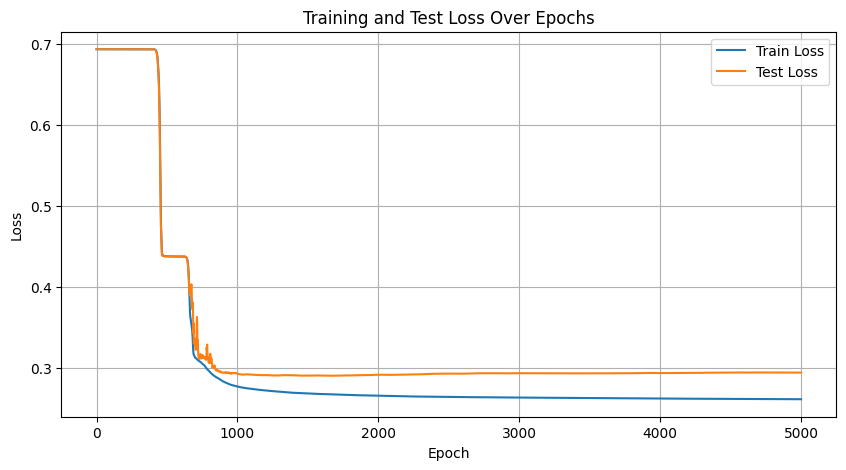

_orig_mod.linears.0.weight
Parameter containing:
tensor([[ 4.0214e-30, -1.1529e-02,  1.0334e-03,  1.0210e-02, -4.7385e-01,
         -8.3473e-02, -1.7550e-02],
        [-1.1908e-02, -4.8695e-19,  2.0789e-01,  1.8810e-02, -1.9079e-02,
          7.2302e-05,  1.3879e-02],
        [-5.4814e-03, -1.8807e-02, -2.7403e-02,  2.7123e-02, -4.5379e-04,
          1.3086e-03, -1.7300e-05],
        [-1.0047e-01, -1.3216e-02, -6.9637e-04, -1.5122e-12,  4.5619e-11,
          3.0002e-05,  2.6966e-03],
        [ 1.0261e+00,  4.8637e-03,  4.3404e-02, -1.2495e-01,  7.9561e-02,
         -5.7907e-01, -8.0932e-02],
        [-3.3698e-01,  3.8737e-02,  2.4002e-02,  7.8801e-02, -4.1323e-01,
         -3.7938e-16, -1.9515e-02],
        [-2.9836e-01,  3.2290e-03,  5.2315e-03, -7.4940e-02, -3.2092e-01,
          1.1436e-02,  1.4732e-33]], requires_grad=True)
_orig_mod.linears.1.weight
Parameter containing:
tensor([[-1.3640e-01, -1.2533e-01,  2.0992e-01, -1.8967e-01, -4.3828e-02,
         -1.4482e-01,  8.9151e-05, -2

In [13]:
model = torch.compile(StableNN(n=X.shape[1], num_layers=3).to(device))
criterion = nn.CrossEntropyLoss()

optimizers = [
    optim.Rprop(model.parameters(), lr=0.0, step_sizes=(torch.finfo(torch.float32).smallest_normal, torch.inf))
]

train(model, criterion, optimizers, epochs=5000)

for name, param in model.named_parameters(): # type: ignore
    print(name)
    print(param)

Muon parameters:
torch.Size([7, 7])
torch.Size([14, 14])
torch.Size([28, 28])
torch.Size([2, 56])

AdamW parameters:
torch.Size([7])
torch.Size([7])
torch.Size([14])
torch.Size([14])
torch.Size([28])
torch.Size([28])
torch.Size([2])
Layer (type:depth-idx)                   Output Shape              Param #
OptimizedModule                          [43152, 2]                --
├─StableNN: 1-1                          [43152, 2]                --
│    └─BatchNorm1d: 2-1                  [43152, 7]                --
│    └─ModuleList: 2-10                  --                        --
│    │    └─BatchNorm1d: 3-1             [43152, 7]                --
│    └─ModuleList: 2-11                  --                        (recursive)
│    │    └─Linear: 3-2                  [43152, 7]                49
│    └─ModuleList: 2-12                  --                        --
│    │    └─BatchNorm1d: 3-3             [43152, 7]                --
│    └─ModuleList: 2-13                  --          

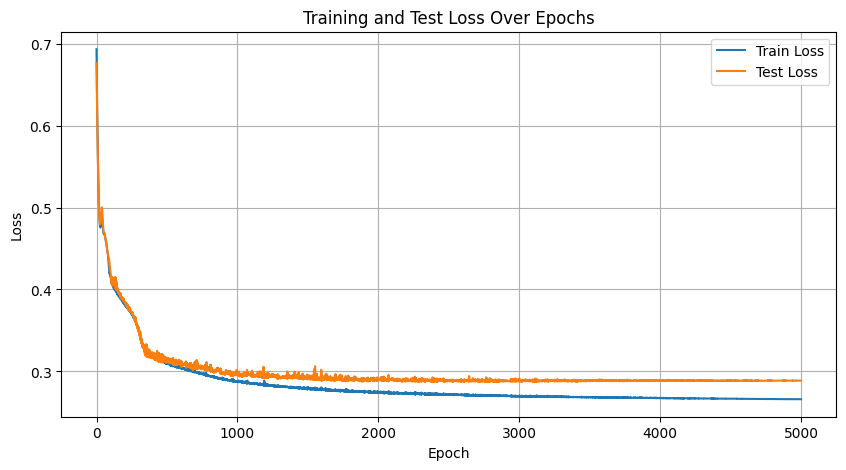

_orig_mod.linears.0.weight
Parameter containing:
tensor([[ 2.1323, -0.5397,  0.1889,  0.3080, -3.5156,  1.5191, -0.5264],
        [-0.5490,  1.4427,  0.1467, -0.7369, -1.0610,  1.8746,  1.0969],
        [ 1.9265, -0.1418,  0.2754, -1.0549,  4.2044, -3.4557, -0.9394],
        [-2.4856,  1.4570,  0.9761, -1.6954,  3.8385, -1.5845,  1.8962],
        [ 0.1457,  0.1919, -2.2701,  0.1137,  2.0981, -0.7606, -2.6941],
        [ 4.8875, -0.2398,  0.2063, -0.1979, -0.4968, -1.1037, -1.3436],
        [-2.2492,  0.3205,  1.3085,  0.1245, -2.2452,  3.6367,  1.0404]],
       requires_grad=True)
_orig_mod.linears.1.weight
Parameter containing:
tensor([[ 5.6365e+00, -3.1097e-01,  6.4944e-01, -1.5494e+00,  1.3686e+00,
         -5.0445e-01, -9.2579e-01,  4.4443e-01, -1.3758e+00, -1.1353e+00,
         -2.8380e-04, -2.3082e+00, -3.3185e+00, -9.3960e-01],
        [ 2.8993e+00, -6.3104e-02,  9.8581e-01, -2.3904e-01,  3.5273e-01,
          1.0275e+00, -9.2330e-01, -1.5348e-01,  1.4449e+00, -6.6499e-01,
     

In [10]:
model = torch.compile(StableNN(n=X.shape[1], num_layers=3).to(device))
criterion = nn.CrossEntropyLoss()

muon_params = []
adamw_params = []

for name, param in model.named_parameters(): # type: ignore
    if (param.ndim >= 2):
        muon_params.append(param)
    else:
        adamw_params.append(param)

print("Muon parameters:")
for p in muon_params:
    print(p.shape)

print()
print("AdamW parameters:")
for p in adamw_params:
    print(p.shape)

optimizers = [
    Muon(muon_params, weight_decay=0.0),
    optim.AdamW(adamw_params, weight_decay=0.0)
]

train(model, criterion, optimizers, epochs=5000)

for name, param in model.named_parameters(): # type: ignore
    print(name)
    print(param)

In [8]:
model = torch.compile(StableNN(n=X.shape[1], num_layers=3).to(device))
criterion = nn.CrossEntropyLoss()

muon_params = []
adamw_params = []

for name, param in model.named_parameters(): # type: ignore
    if (param.ndim >= 2):
        muon_params.append(param)
    else:
        adamw_params.append(param)

print("Muon parameters:")
for p in muon_params:
    print(p.shape)

print()
print("AdamW parameters:")
for p in adamw_params:
    print(p.shape)

optimizers = [
    Muon(muon_params, weight_decay=0.0),
    optim.AdamW(adamw_params, weight_decay=0.0)
]

train(model, criterion, optimizers, epochs=5000)

for name, param in model.named_parameters(): # type: ignore
    print(name)
    print(param)

Muon parameters:
torch.Size([7, 7])
torch.Size([14, 14])
torch.Size([28, 28])
torch.Size([2, 56])

AdamW parameters:
torch.Size([7])
torch.Size([7])
torch.Size([14])
torch.Size([14])
torch.Size([28])
torch.Size([28])
torch.Size([2])
Layer (type:depth-idx)                   Output Shape              Param #
OptimizedModule                          [43152, 2]                --
├─StableNN: 1-1                          [43152, 2]                --
│    └─BatchNorm1d: 2-1                  [43152, 7]                --
│    └─ModuleList: 2-10                  --                        --
│    │    └─BatchNorm1d: 3-1             [43152, 7]                --
│    └─ModuleList: 2-11                  --                        (recursive)
│    │    └─Linear: 3-2                  [43152, 7]                49
│    └─ModuleList: 2-12                  --                        (recursive)
│    │    └─CustomActivation: 3-3        [43152, 7]                14
│    └─ModuleList: 2-13                  -- 

KeyboardInterrupt: 

Muon parameters:
torch.Size([7, 14])
torch.Size([14, 28])
torch.Size([28, 56])
torch.Size([2, 112])

AdamW parameters:
torch.Size([2])
Layer (type:depth-idx)                   Output Shape              Param #
OptimizedModule                          [43152, 2]                --
├─StableNN: 1-1                          [43152, 2]                --
│    └─BatchNorm1d: 2-1                  [43152, 7]                --
│    └─CReLU: 2-2                        [43152, 14]               --
│    └─ModuleList: 2-13                  --                        --
│    │    └─BatchNorm1d: 3-1             [43152, 14]               --
│    └─ModuleList: 2-14                  --                        (recursive)
│    │    └─Linear: 3-2                  [43152, 7]                98
│    └─ModuleList: 2-15                  --                        --
│    │    └─BatchNorm1d: 3-3             [43152, 7]                --
│    └─ModuleList: 2-16                  --                        --
│    │    └

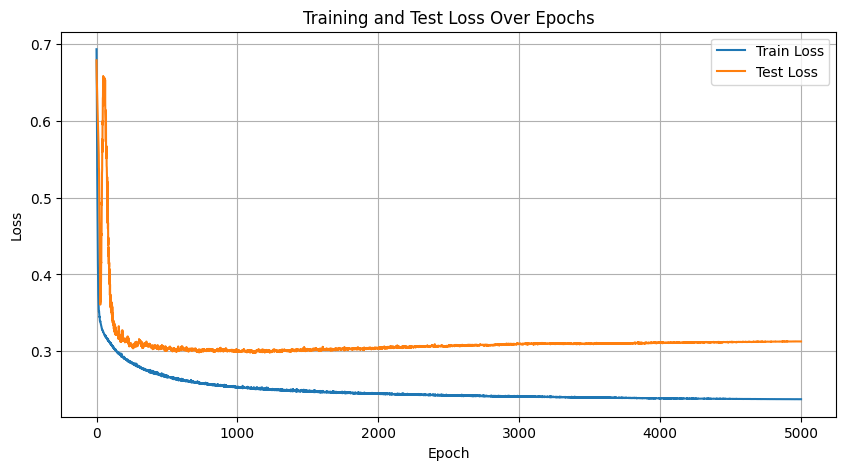

_orig_mod.linears.0.weight
Parameter containing:
tensor([[-0.3226,  0.5494,  1.4438, -0.4536, -1.2193, -0.5756, -0.4195, -1.4275,
          0.5229,  0.0509,  0.6246, -0.2336,  0.5169,  1.7000],
        [-0.6358,  0.5240, -0.8274, -0.4145, -0.3418, -0.5465,  1.4570,  1.7271,
         -0.5361, -0.8232,  0.3163,  0.1736, -2.1185,  0.4473],
        [-0.2397,  2.2451,  0.5930, -0.3705,  0.9042, -0.5748,  0.0667,  0.8778,
          1.2061,  1.1897, -0.0209, -1.4963, -0.2285,  1.0297],
        [ 0.1121, -0.2657,  0.3559, -0.4999,  1.9031, -0.1913,  0.8555,  1.4838,
          0.5939, -0.9652, -0.9859,  1.4985, -1.6456, -0.2882],
        [-0.4516, -0.3316,  0.2553, -0.0302, -0.4907, -1.7968, -0.3850,  0.2302,
         -0.2901, -0.4607,  0.0198, -0.9330,  2.5381,  0.7006],
        [-0.1482,  0.1019,  0.6112, -0.0391, -1.9899,  0.5851, -0.2096,  0.7466,
          0.0738, -1.1768, -0.1051,  0.4942,  0.7226, -0.1771],
        [-0.8546, -0.8410,  1.7356, -0.7786, -0.2339,  0.5758,  1.1760,  0.6502,


In [13]:
# postnorm(postnomrm(x) + residual)

model = torch.compile(StableNN(n=X.shape[1], num_layers=3).to(device))
criterion = nn.CrossEntropyLoss()

muon_params = []
adamw_params = []

for name, param in model.named_parameters(): # type: ignore
    if (param.ndim >= 2):
        muon_params.append(param)
    else:
        adamw_params.append(param)

print("Muon parameters:")
for p in muon_params:
    print(p.shape)

print()
print("AdamW parameters:")
for p in adamw_params:
    print(p.shape)

optimizers = [
    Muon(muon_params, weight_decay=0.0),
    optim.AdamW(adamw_params, weight_decay=0.0)
]

train(model, criterion, optimizers, epochs=5000)

for name, param in model.named_parameters(): # type: ignore
    print(name)
    print(param)

In [11]:
# postnorm(postnomrm(x) + residual)

model = torch.compile(StableNN(n=X.shape[1], num_layers=3).to(device))
criterion = nn.CrossEntropyLoss()

muon_params = []
adamw_params = []

for name, param in model.named_parameters(): # type: ignore
    if (param.ndim >= 2):
        muon_params.append(param)
    else:
        adamw_params.append(param)

print("Muon parameters:")
for p in muon_params:
    print(p.shape)

print()
print("AdamW parameters:")
for p in adamw_params:
    print(p.shape)

optimizers = [
    Muon(muon_params, weight_decay=0.0),
    optim.AdamW(adamw_params, weight_decay=0.0)
]

train(model, criterion, optimizers, epochs=5000)

for name, param in model.named_parameters(): # type: ignore
    print(name)
    print(param)

Muon parameters:
torch.Size([7, 14])
torch.Size([14, 28])
torch.Size([28, 56])
torch.Size([2, 112])

AdamW parameters:
torch.Size([2])
Layer (type:depth-idx)                   Output Shape              Param #
OptimizedModule                          [43152, 2]                --
├─StableNN: 1-1                          [43152, 2]                --
│    └─BatchNorm1d: 2-1                  [43152, 7]                --
│    └─CReLU: 2-2                        [43152, 14]               --
│    └─ModuleList: 2-11                  --                        --
│    │    └─BatchNorm1d: 3-1             [43152, 14]               --
│    └─ModuleList: 2-12                  --                        (recursive)
│    │    └─Linear: 3-2                  [43152, 7]                98
│    └─ModuleList: 2-13                  --                        --
│    │    └─BatchNorm1d: 3-3             [43152, 7]                --
│    │    └─BatchNorm1d: 3-4             [43152, 7]                --
│    └─CReL

KeyboardInterrupt: 